# 01. Explore Data
Based on the analysis structure:
1. **Overview (Status Quo)**: KPIs and Timeline.
2. **Geospatial Insights (Location)**: Region and Route maps.
3. **Root Cause Analysis (Factors)**: Infrastructure, Alerts, Environment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import textwrap
import geopandas as gpd
from shapely import wkt
import plotly.graph_objects as go
import json
import numpy as np
import scipy.stats as stats

import notebook_const

from src import utils
from src import const

# データの読み込み

In [2]:
base_df = utils.load_data()
print(f"Total records: {len(base_df):,}")
print(f"Date range: {base_df['start_date'].min()} to {base_df['start_date'].max()}")

Total records: 16,332,273
Date range: 20251118 to 20251208


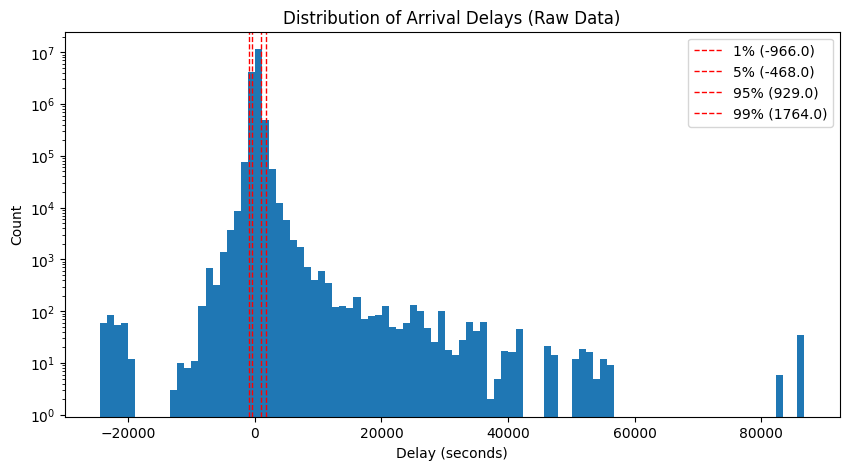

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(base_df['arrival_delay'], bins=100) 
plt.title('Distribution of Arrival Delays (Raw Data)')
plt.xlabel('Delay (seconds)')
plt.ylabel('Count')
plt.yscale('log')

# Add percentile lines
percentiles = [0.01, 0.05, 0.95, 0.99]
for p in percentiles:
    value = base_df['arrival_delay'].quantile(p)
    plt.axvline(x=value, color='red', linestyle='--', linewidth=1, label=f'{int(p*100)}% ({value:.1f})')

plt.legend()
plt.show()

In [4]:
per001 = base_df['arrival_delay'].quantile(0.01)
per099 = base_df['arrival_delay'].quantile(0.99)

In [5]:
# Filter outliers
base_df_filtered = base_df[(base_df['arrival_delay'] >= per001) & (base_df['arrival_delay'] <= per099)]
print(f"Records before filtering outliers: {len(base_df):,}")
del base_df
base_df_filtered = base_df_filtered[base_df_filtered['alert_effect_detour'] >= 0]
print(f"Records after filtering outliers: {len(base_df_filtered):,}")

Records before filtering outliers: 16,332,273
Records after filtering outliers: 16,006,041


遅延分布の約98%が-15分から30分の範囲に収まっていることが確認できます。
本プロジェクトでは、外れ値を除去しデータの質を担保するため、この範囲内のデータに限定して分析およびモデル構築を行います。

In [6]:
base_df_filtered.isnull().sum()

route_id                        0
trip_id                         0
start_date                      0
arrival_day_offset              0
direction_id                    0
stop_id                         0
stop_sequence                   0
region_id                    1222
lat_sin                         0
lat_cos                         0
lon_sin                         0
lon_cos                         0
distance_from_downtown_km       0
scheduled_arrival_time          0
actual_arrival_time             0
arrival_delay                   0
time_bucket                     0
hour_of_day                     0
day_of_week                     0
corrected_service_date          0
has_active_alert                0
high_impact_alert_count         0
alert_police_activity           0
alert_construction              0
alert_technical_problem         0
alert_effect_no_service         0
alert_effect_detour             0
alert_severity_score            0
dtype: int64

一部のバス停において、region_idが欠損している（どのregionにも属していない）ケースが確認されます。

In [7]:
# KPI Calculation
avg_delay = base_df_filtered['arrival_delay'].mean()
delay_rate = (base_df_filtered['arrival_delay'] > 60).mean() * 100 # > 1 min
print(f"Overall Average Delay: {avg_delay:.2f} seconds")
print(f"Delay Rate (>1 min): {delay_rate:.2f}%")

# Top Routes
top_routes = base_df_filtered.groupby('route_id')['arrival_delay'].mean().sort_values(ascending=False).head(3)
route_fd = pd.read_csv(const.ROUTES_TXT, usecols=['route_id', 'route_short_name', 'route_long_name'])
route_fd['route_name'] = route_fd['route_short_name'] + " " + route_fd['route_long_name']
print("\nTop 3 Delayed Routes (Avg) [route_id]:")
top_routes = top_routes.reset_index().merge(route_fd, on='route_id', how='inner')
print(top_routes[['route_name', 'arrival_delay']])

# Top Regions
top_regions = base_df_filtered.groupby('region_id')['arrival_delay'].mean().sort_values(ascending=False).head(3)
print("\nTop 3 Delayed Regions (Avg):")
print(top_regions)

Overall Average Delay: 155.09 seconds
Delay Rate (>1 min): 58.01%

Top 3 Delayed Routes (Avg) [route_id]:
                              route_name  arrival_delay
0  503 Aldergrove/Surrey Central Station     535.528767
1          418 Kingswood/22nd St Station     496.885278
2      602 Tsawwassen Heights/Bridgeport     376.632896

Top 3 Delayed Regions (Avg):
region_id
langley                    308.229288
langley_city               278.144948
tsawwassen_first_nation    198.395016
Name: arrival_delay, dtype: float64


# 1. Overview

## Region ID欠損データの特定

In [8]:
null_region_df = base_df_filtered.loc[base_df_filtered['region_id'].isnull()]
null_region_df[['stop_id']].drop_duplicates()

,stop_id
5282063,9956


In [9]:
trip_df = pd.read_csv(const.TRIPS_TXT)
stop_times_df = pd.read_csv(const.STOP_TIMES_TXT, usecols=['trip_id', 'stop_id', 'stop_sequence'])
stop_times_df['stop_id'] = stop_times_df['stop_id'].astype(str)

trip_stop_times_df = stop_times_df.merge(trip_df, on='trip_id', how='left')
stop_route_counts = trip_stop_times_df.groupby('stop_id').agg({'route_id': 'nunique'}).reset_index()
stop_route_counts.rename(columns={'route_id': 'route_count_at_stop'}, inplace=True)
base_df_filtered = base_df_filtered.merge(stop_route_counts, on='stop_id', how='left')

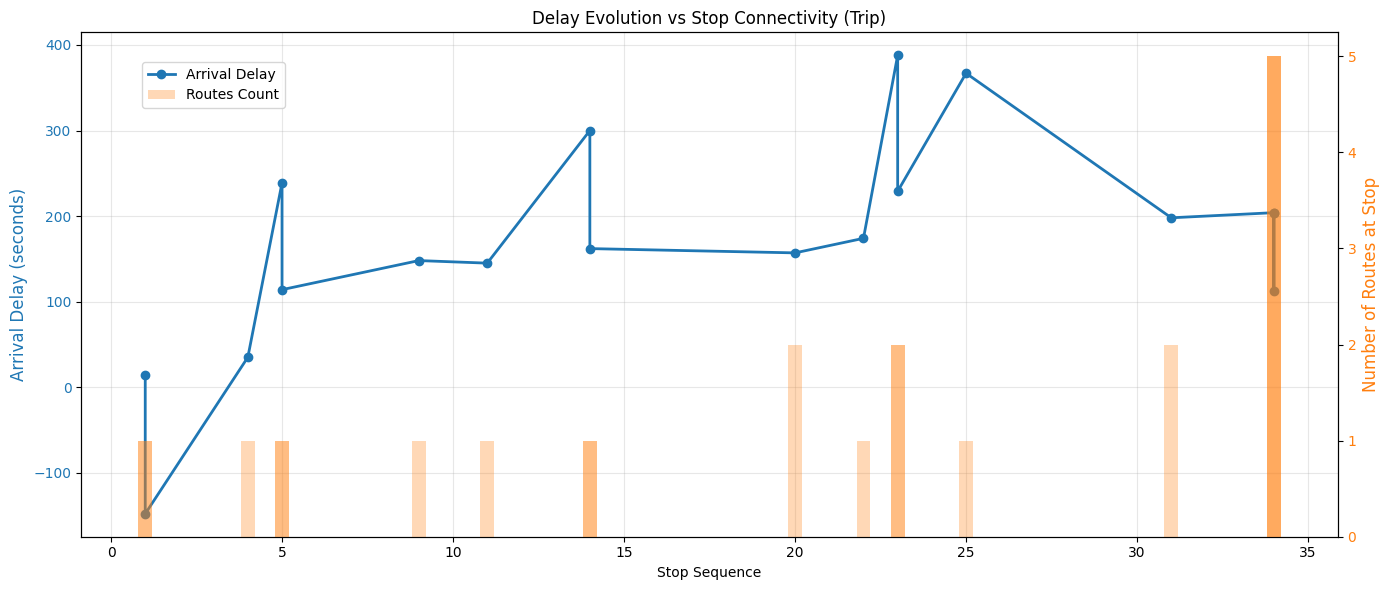

In [10]:
stop_times_df['trip_id'] = stop_times_df['trip_id'].astype(str)

target_df = base_df_filtered[
    (base_df_filtered['trip_id'] == '14684746') &
    (base_df_filtered['start_date'] == '20251121')
]

trip_data = target_df.sort_values('stop_sequence').copy()
trip_data['routes_at_stop'] = trip_data['stop_id'].map(stop_route_counts.set_index('stop_id')['route_count_at_stop'])

# Create visualization
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Arrival Delay (Left Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Stop Sequence')
ax1.set_ylabel('Arrival Delay (seconds)', color=color1, fontsize=12)
ax1.plot(trip_data['stop_sequence'], trip_data['arrival_delay'], 
         color=color1, marker='o', linestyle='-', linewidth=2, label='Arrival Delay')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Plot 2: Number of Routes at Stop (Right Axis)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Number of Routes at Stop', color=color2, fontsize=12)
ax2.bar(trip_data['stop_sequence'], trip_data['routes_at_stop'], 
        color=color2, alpha=0.3, width=0.4, label='Routes Count')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Delay Evolution vs Stop Connectivity (Trip)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

データ取得が2分間隔で行われたため、特定のバス停に対して複数の遅延データが存在する場合や、逆にデータが欠損している場合があります。
1トリップ・1バス停につき1つの遅延データとなるよう、集約処理と補完を行う必要があります。

## Timeline Metrics
時間帯や曜日による遅延特性の分析。
### 10分間隔、曜日別、ヒートマップによる分析

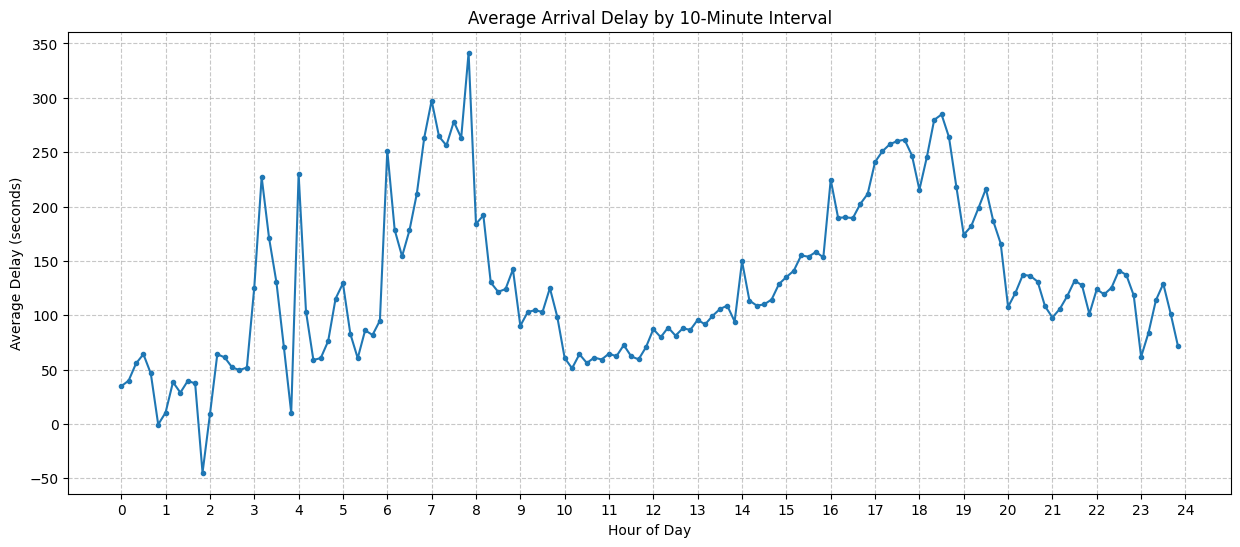

In [11]:
base_df_filtered['minute'] = base_df_filtered['actual_arrival_time'].dt.minute
base_df_filtered['minute_bin'] = (base_df_filtered['minute'] // 10) * 10

delay_by_10min = base_df_filtered.groupby(['hour_of_day', 'minute_bin'])['arrival_delay'].mean().reset_index()
delay_by_10min['time_axis'] = delay_by_10min['hour_of_day'] + delay_by_10min['minute_bin'] / 60

plt.figure(figsize=(15, 6))
plt.plot(delay_by_10min['time_axis'], delay_by_10min['arrival_delay'], marker='.', linestyle='-')
plt.title('Average Arrival Delay by 10-Minute Interval')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delay (seconds)')
plt.xticks(range(0, 25))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

1日の中で2つのピークが確認できます。1つ目のピークは朝7時頃にあり、通勤ラッシュの影響と考えられます。
2つ目のピークは夕方17時頃ですが、朝と比較して緩やかな分布となっており、帰宅時間の分散を示唆しています。

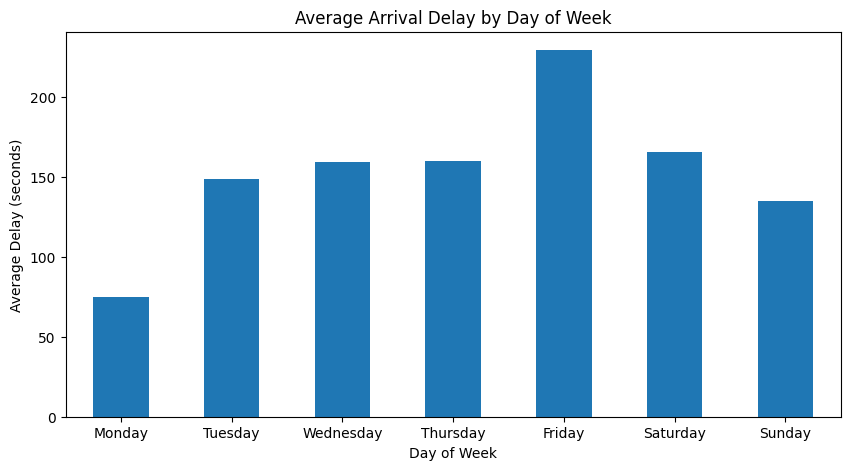

In [12]:
# Map day_of_week to names (ISODOW: 1=Monday, 7=Sunday)
day_map = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
daily_delays = base_df_filtered.groupby('day_of_week')['arrival_delay'].mean()
daily_delays.index = daily_delays.index.map(day_map)

daily_delays.plot(kind='bar', figsize=(10, 5))
plt.title('Average Arrival Delay by Day of Week')
plt.xticks(rotation=0)
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (seconds)')
plt.show()

金曜日に最も遅延が大きくなる傾向があります。週末に向けた移動需要の増加が要因として考えられます。
一方、月曜日は遅延が最も少なく、週初めの交通量の少なさや、ハイブリッドワーク等の勤務形態の影響が推察されます。

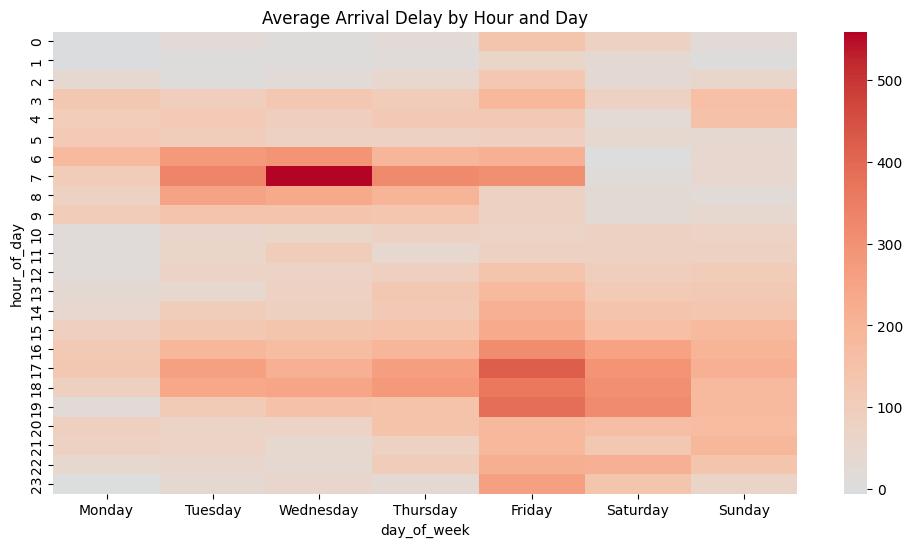

In [13]:
plt.figure(figsize=(12, 6))
pivot_data = base_df_filtered.pivot_table(index='hour_of_day', columns='day_of_week', values='arrival_delay', aggfunc='mean')
pivot_data.columns = pivot_data.columns.map(day_map)

sns.heatmap(pivot_data, cmap='coolwarm', center=0, annot=False)
plt.title('Average Arrival Delay by Hour and Day')
plt.show()

ヒートマップにより、より詳細な傾向が把握できます。週半ばの朝7時頃に明確なピークが存在します。
また、週末（金曜日）の夜間に遅延が増加しており、夜間の移動需要の高まりを示唆しています。

# 2. Geospatial Insights (Location)
路線ごとの運行頻度と遅延傾向の分析。

In [14]:
route_df = pd.read_csv(const.ROUTES_TXT)
trip_df = pd.read_csv(const.TRIPS_TXT, usecols=['route_id', 'trip_id', 'direction_id', 'trip_headsign'])
stop_df = pd.read_csv(const.STOPS_TXT, usecols=['stop_id', 'stop_name', 'stop_lat', 'stop_lon'])
stop_times_df = pd.read_csv(const.STOP_TIMES_TXT, usecols=['trip_id', 'stop_id', 'stop_sequence'])

route_df['route_name'] = route_df['route_short_name'] + ' ' + route_df['route_long_name']

# use only bus routes (route_type == 3)
bus_route = route_df[route_df['route_type'] == 3][['route_id', 'route_name']]

# count trips per route
bus_trip = trip_df.merge(bus_route, on=['route_id'], how='inner')
route_names = bus_trip.groupby(['route_id', 'route_name']).agg(trip_count=('trip_id', 'size'), trip_id=('trip_id', 'median')).reset_index()
route_names['trip_id'] = route_names['trip_id'].astype(int)

# Calculate trip locations first (dictionary or dataframe)
# Merging stop_times with stops to get lat/lon for all trips at once
trip_locations = stop_times_df.merge(stop_df, on='stop_id', how='left') \
    .sort_values(['trip_id', 'stop_sequence'])

route_names.head()

,route_id,route_name,trip_count,trip_id
0,10232,256 Whitby Estate/Park Royal/Spuraway,88,14706490
1,11201,033 29th Avenue Station/UBC,253,14683778
2,11692,364 Langley Centre/Scottsdale,263,14715054
3,11693,388 22nd St Station/Carvolth Exchange,57,14716180
4,11696,609 South Delta Exchange/Ladner Exchange,156,14722956


## Trip Count Analysis

In [15]:
# Prepare data for Plotly
plot_data = route_names.sort_values('trip_count', ascending=False).head(10).reset_index(drop=True)

# Assign colors to each route
colors = px.colors.qualitative.Plotly
plot_data['color'] = [colors[i % len(colors)] for i in range(len(plot_data))]

# Calculate line widths based on trip_count
min_trips = plot_data['trip_count'].min()
max_trips = plot_data['trip_count'].max()

def calculate_width(count):
    if max_trips == min_trips:
        return 5
    return 3 + (count - min_trips) / (max_trips - min_trips) * 7

fig = go.Figure()

for idx, row in plot_data.iterrows():
    # Retrieve locations for the trip
    subset = trip_locations[trip_locations['trip_id'] == row['trip_id']]
    
    if not subset.empty:
        lats = subset['stop_lat']
        lons = subset['stop_lon']
            
        # Dynamic line width
        width = calculate_width(row['trip_count'])
        
        # Wrap legend name to approx. half width (20 chars) for narrower legend
        name_text = f"{row['route_name']} ({row['trip_count']})"
        wrapped_name = "<br>".join(textwrap.wrap(name_text, width=20))
        
        fig.add_trace(
            go.Scattermap(
                lat=lats,
                lon=lons,
                mode='lines',
                line=dict(width=width, color=row['color']),
                name=wrapped_name, 
                hoverinfo='text',
                text=f"{row['route_name']}<br>Trips: {row['trip_count']}",
                showlegend=True
            )
        )

fig.update_layout(
    height=600,
    title=dict(
        text="Route Usage Analysis (Top 10) - Scaled by Trip Count",
        x=0.5,
        xanchor='center'
    ),
    map=dict(
        style="open-street-map", 
        center=dict(lat=49.25, lon=-123.02),
        zoom=10
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    legend=dict(title="Route (Trip Count)")
)

fig.show()

運行本数はダウンタウン周辺およびUBC（ブリティッシュコロンビア大学）発着の路線で多く、これらの地域に需要が集中していることが確認できます。

## Arrival Delay Visualization (Graph & Map)

In [16]:
import plotly.graph_objects as go
import plotly.express as px
import textwrap

top_delays = base_df_filtered.groupby(['route_id', 'trip_id']).agg({'arrival_delay': 'mean'}).reset_index() \
    .groupby('route_id')['arrival_delay'].mean().reset_index()

# Merge with route info (trip_id reference for shape)
top_delays = top_delays.merge(route_names[['route_id', 'route_name', 'trip_id']], on='route_id', how='inner')

# Filter for Top 10 delayed routes
plot_data = top_delays.sort_values('arrival_delay', ascending=False).head(10).reset_index(drop=True)

# Assign colors to each route
colors = px.colors.qualitative.Plotly
plot_data['color'] = [colors[i % len(colors)] for i in range(len(plot_data))]

# Calculate line widths based on arrival_delay
min_delay = plot_data['arrival_delay'].min()
max_delay = plot_data['arrival_delay'].max()

def calculate_width_delay(delay):
    if max_delay == min_delay:
        return 5
    return 3 + (delay - min_delay) / (max_delay - min_delay) * 7

fig = go.Figure()

for idx, row in plot_data.iterrows():
    # Retrieve locations for the trip using trip_id from route_names
    subset = trip_locations[trip_locations['trip_id'] == row['trip_id']]
    
    if not subset.empty:
        lats = subset['stop_lat']
        lons = subset['stop_lon']
            
        # Dynamic line width
        width = calculate_width_delay(row['arrival_delay'])
        
        # Wrap legend name
        name_text = f"{row['route_name']} ({row['arrival_delay']:.1f}s)"
        wrapped_name = "<br>".join(textwrap.wrap(name_text, width=20))
        
        fig.add_trace(
            go.Scattermap(
                lat=lats,
                lon=lons,
                mode='lines',
                line=dict(width=width, color=row['color']),
                name=wrapped_name, 
                hoverinfo='text',
                text=f"{row['route_name']}<br>Avg Delay: {row['arrival_delay']:.1f}s",
                showlegend=True
            )
        )

# Layout adjustments
fig.update_layout(
    height=600,
    title=dict(
        text="Top 10 Routes by Average Arrival Delay",
        x=0.5,
        xanchor='center'
    ),
    map=dict(
        style="open-street-map", 
        center=dict(lat=49.25, lon=-123.12),
        zoom=10
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    legend=dict(title="Route (Avg Delay)")
)

fig.show()

運行本数がバンクーバー中心部に集中しているのに対し、遅延は郊外路線で顕著です。特にBridgeport Station発の路線がワースト10路線のうち4つを占めています。
また、地図上の可視化から、Route 503を除く上位の遅延路線のほぼ全てが、橋梁による渡河を含むルートであることが確認できます（ボトルネックの可能性）。

In [17]:
route_stats = base_df_filtered.groupby('route_id').agg({
    'trip_id': 'nunique',
    'arrival_delay': 'median'
}).reset_index()

route_stats.columns = ['route_id', 'trip_count', 'avg_delay']

routes_df = pd.read_csv(const.ROUTES_TXT, dtype={'route_id': str})
route_stats = route_stats.merge(routes_df[['route_id', 'route_short_name', 'route_long_name']], on='route_id', how='left')

correlation = route_stats['trip_count'].corr(route_stats['avg_delay'])
fig = px.scatter(
    route_stats,
    x='trip_count',
    y='avg_delay',
    hover_data=['route_short_name', 'route_long_name'],
    title=f'Correlation between Operation Frequency (Trip Count) and Average Delay by Route (Correlation: {correlation:.3f})',
    labels={'trip_count': 'Number of Trips', 'avg_delay': 'Average Delay (seconds)'}
)

fig.update_layout(
    xaxis_title="Number of Trips",
    yaxis_title="Average Delay (s)"
)

fig.show()

In [18]:
# Load regions data
regions_df = pd.read_csv(const.REGIONS_CSV)

# Clean WKT (remove SRID prefix if present)
regions_df['boundary_clean'] = regions_df['boundary'].apply(lambda x: x.split(';')[-1] if isinstance(x, str) and ';' in x else x)

# Convert to GeoDataFrame
# Filter out rows where boundary is null or invalid if necessary
regions_df = regions_df.dropna(subset=['boundary_clean'])
regions_df['geometry'] = regions_df['boundary_clean'].apply(wkt.loads)
gdf_regions = gpd.GeoDataFrame(regions_df, geometry='geometry')

# Calculate mean delay by region
region_delays = base_df_filtered.groupby('region_id')['arrival_delay'].mean().reset_index()

gdf_regions = gdf_regions.merge(region_delays, on='region_id', how='left')
gdf_regions['arrival_delay'] = gdf_regions['arrival_delay'].fillna(0)

# Stops in no region
stops_no_region = null_region_df.groupby(['stop_id', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']).agg({'arrival_delay': 'mean'}).reset_index()
stops_no_region['stop_lat'] = np.degrees(np.arctan2(stops_no_region['lat_sin'], stops_no_region['lat_cos']))
stops_no_region['stop_lon'] = np.degrees(np.arctan2(stops_no_region['lon_sin'], stops_no_region['lon_cos']))

geojson_regions = json.loads(gdf_regions.to_json())

fig = go.Figure()

# Choropleth for Regions
fig.add_trace(
    go.Choroplethmap(
        geojson=geojson_regions,
        locations=gdf_regions['region_id'],
        featureidkey="properties.region_id",
        z=gdf_regions['arrival_delay'],
        colorscale="YlOrRd",
        marker_opacity=0.6,
        marker_line_width=1,
        name='Region Delay',
        text=gdf_regions.apply(lambda row: f"{row['region_name']}<br>Avg Delay: {row['arrival_delay']:.1f}s", axis=1),
        hoverinfo='text'
    )
)

# Scatter for No Region Stops (Outliers)
if not stops_no_region.empty:
    fig.add_trace(
        go.Scattermap(
            lat=stops_no_region['stop_lat'],
            lon=stops_no_region['stop_lon'],
            mode='markers',
            marker=dict(
                size=6,
                color='blue',
                opacity=0.8
            ),
            name='No Region Stops',
            text=stops_no_region.apply(lambda row: f"Stop ID: {row['stop_id']}<br>Delay: {row['arrival_delay']:.2f}s", axis=1),
            hoverinfo='text'
        )
    )

fig.update_layout(
    height=600,
    title=dict(
        text="Average Arrival Delay by Region",
        x=0.5,
        xanchor='center'
    ),
    map=dict(
        style="open-street-map",
        center=dict(lat=49.2827, lon=-123.1207),
        zoom=8
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    legend=dict(title="Legend")
)

fig.show()

地域（Region）別の遅延状況を確認すると、Langley地区において遅延が突出して大きい一方、White Rock地区では比較的小さい傾向が見られます。また、どのregionにも所属していないバス停は City of Maple Ridge に属していることがわかります。

In [19]:
gdf_boundary = gpd.read_file(const.BOUNDARY_GEOJSON)

unique_stops = base_df_filtered[['stop_id', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']].drop_duplicates()
unique_stops['stop_lat'] = np.degrees(np.arctan2(unique_stops['lat_sin'], unique_stops['lat_cos']))
unique_stops['stop_lon'] = np.degrees(np.arctan2(unique_stops['lon_sin'], unique_stops['lon_cos']))

gdf_stops = gpd.GeoDataFrame(
    unique_stops,
    geometry=gpd.points_from_xy(unique_stops.stop_lon, unique_stops.stop_lat),
    crs="EPSG:4326"
)

gdf_joined = gpd.sjoin(gdf_stops, gdf_boundary[['name', 'geometry']], how="left", predicate="within")

stop_to_area = gdf_joined.set_index('stop_id')['name'].to_dict()

base_df_filtered['local_area_name'] = base_df_filtered['stop_id'].map(stop_to_area)

area_delays = base_df_filtered.groupby('local_area_name')['arrival_delay'].mean().reset_index()
area_delays.rename(columns={'local_area_name': 'name'}, inplace=True)

gdf_boundary_merged = gdf_boundary.merge(area_delays, on='name', how='left')
gdf_boundary_merged['arrival_delay'] = gdf_boundary_merged['arrival_delay'].fillna(0)

# Prepare GeoJSON
geojson_boundary = json.loads(gdf_boundary_merged.to_json())

fig = go.Figure()

fig.add_trace(
    go.Choroplethmap(
        geojson=geojson_boundary,
        locations=gdf_boundary_merged['name'],
        featureidkey="properties.name",
        z=gdf_boundary_merged['arrival_delay'],
        colorscale="YlOrRd",
        marker_opacity=0.6,
        marker_line_width=1,
        name='Local Area Delay',
        text=gdf_boundary_merged.apply(lambda row: f"{row['name']}<br>Avg Delay: {row['arrival_delay']:.1f}s", axis=1),
        hoverinfo='text'
    )
)

fig.update_layout(
    height=600,
    title=dict(
        text="Average Arrival Delay by Vancouver Area",
        x=0.5,
        xanchor='center'
    ),
    map=dict(
        style="open-street-map",
        center=dict(lat=49.25, lon=-123.12),
        zoom=10
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    legend=dict(title="Legend")
)

fig.show()

バンクーバー市内をより細かいエリア（Local Area）に分割して分析すると、特定のエリアで遅延が顕著に増加していることが確認できます。

# 3. Root Cause Analysis (Factors)

## Sudden Events: Alerts
リアルタイムアラートが遅延に与える影響の分析。

**分析アプローチの改善:**
厳密なtrip_idマッチングではデータ損失が大きいため、分布比較および（ルート、時間帯）による制御付き集約を行い、コンテキストを考慮した比較を行います。

In [20]:
alert_delays = base_df_filtered[base_df_filtered['has_active_alert'] == True]['arrival_delay']
no_alert_delays = base_df_filtered[base_df_filtered['has_active_alert'] == False]['arrival_delay']

alert_size, no_alert_size = len(alert_delays), len(no_alert_delays)
full_size = alert_size + no_alert_size
print(f'Sample Size - Alert: {alert_size} ({alert_size/full_size:.2%}), No Alert: {no_alert_size} ({no_alert_size/full_size:.2%})')

Sample Size - Alert: 7836576 (48.96%), No Alert: 8169465 (51.04%)


Alert有無によるサンプルサイズを確認した結果、両群ともに統計的検定に十分なサイズが確保されているため、ダウンサンプリング等は行わず、全データを用いて統計的比較を行います。

Mann-Whitney U Test: p-value = 0.0000e+00 (Significant difference if < 0.05)
Mean Delay -> Alert: 198.79s, No Alert: 113.18s


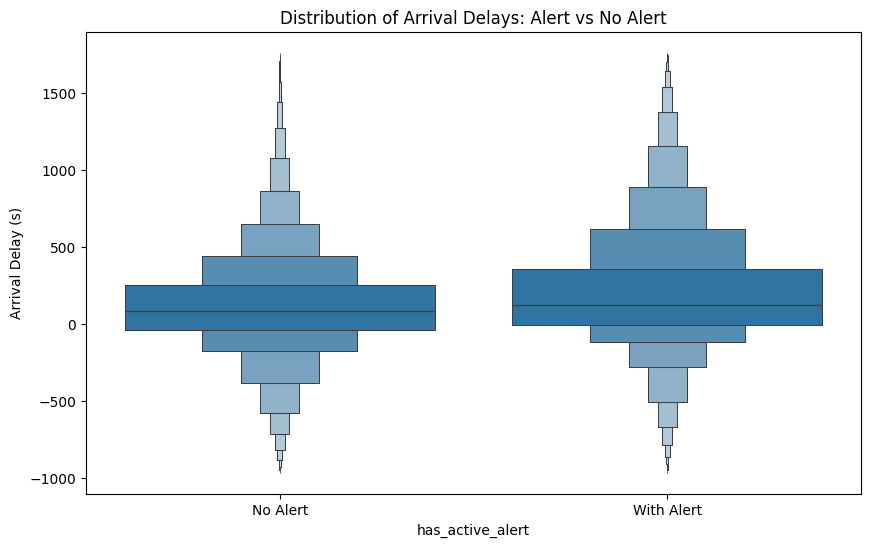

In [21]:
u_stat, p_val = stats.mannwhitneyu(alert_delays, no_alert_delays, alternative='two-sided')
print(f"Mann-Whitney U Test: p-value = {p_val:.4e} (Significant difference if < 0.05)")
print(f"Mean Delay -> Alert: {alert_delays.mean():.2f}s, No Alert: {no_alert_delays.mean():.2f}s")

plt.figure(figsize=(10, 6))
sns.boxenplot(x='has_active_alert', y='arrival_delay', data=base_df_filtered)
plt.title('Distribution of Arrival Delays: Alert vs No Alert')
plt.xticks([0, 1], ['No Alert', 'With Alert'])
plt.ylabel('Arrival Delay (s)')
plt.show()

迂回や工事等のAlertの有無による遅延への影響を比較した結果、Alertが存在する場合、統計的有意に平均遅延が約1分増加していることが確認されました。

## Infrastructure Factors
Analysis of Train Station proximity and Multi-Route Hubs.

In [22]:
from sklearn.neighbors import BallTree

# A. Identify Rail/Train Stops
# ----------------------------
# 1. Load GTFS files
gtfs_dir = const.GTFS_STATIC_DIR
routes_df = pd.read_csv(const.ROUTES_TXT)
trips_df = pd.read_csv(const.TRIPS_TXT)
stop_times_df_full = pd.read_csv(const.STOP_TIMES_TXT, usecols=['trip_id', 'stop_id'])
stop_times_df_full['stop_id'] = stop_times_df_full['stop_id'].astype(str)
stops_df = pd.read_csv(const.STOPS_TXT, usecols=['stop_id', 'stop_name', 'stop_lat', 'stop_lon'])
stops_df['stop_id'] = stops_df['stop_id'].astype(str)

# 2. Filter for Rail Routes (Type 0=Tram, 1=Subway, 2=Rail)
#    Usually buses are type 3.
rail_routes = routes_df[routes_df['route_type'].isin([0, 1, 2])]
rail_route_ids = rail_routes['route_id'].unique()

print(f"Found {len(rail_route_ids)} rail routes.")

# 3. Get Rail Trips and Stops
rail_trips = trips_df[trips_df['route_id'].isin(rail_route_ids)]['trip_id'].unique()
rail_stats_stop_ids = stop_times_df_full[stop_times_df_full['trip_id'].isin(rail_trips)]['stop_id'].unique()
rail_stops = stops_df[stops_df['stop_id'].isin(rail_stats_stop_ids)].copy()

print(f"Found {len(rail_stops)} rail station stops (platforms/entrances).")

# B. Find ALL Bus Stops within 500m of each Rail Stop
# ---------------------------------------------------
# 1. Get Lat/Lon of all unique Bus Stops in our analyis dataset
bus_stop_ids_in_data = base_df_filtered['stop_id'].unique()

bus_stops = stops_df[stops_df['stop_id'].isin(bus_stop_ids_in_data)].copy()
print(f"Matched {len(bus_stops)} bus stops from GTFS data.")

if len(bus_stops) == 0:
    print("Error: No bus stops matched. Check IDs.")
else:
    # 2. Use BallTree for query_radius search
    #    Convert lat/lon to radians for BallTree (Haversine metric)
    bus_stops_rad = np.deg2rad(bus_stops[['stop_lat', 'stop_lon']].values)
    rail_stops_rad = np.deg2rad(rail_stops[['stop_lat', 'stop_lon']].values)
    
    # Haversine metric requires (lat, lon) in radians
    # BallTree expects sample as [lat, lon] if metric='haversine'
    tree = BallTree(rail_stops_rad, metric='haversine')
    
    # 500 meters radius
    # Earth radius ~ 6371 km = 6371000 m
    radius_meters = 500
    radius_rad = radius_meters / 6371000
    
    # Query for each bus stop: is any rail stop within radius?
    # query_radius returns an array of indices. If array is not empty, it's near.
    counts = tree.query_radius(bus_stops_rad, r=radius_rad, count_only=True)
    
    # Flag
    bus_stops['is_near_station'] = counts > 0
    
    # Create the set of "near station" stop_ids
    station_connected_stop_ids = set(bus_stops[bus_stops['is_near_station']]['stop_id'].unique())
    
    print(f" identified {len(station_connected_stop_ids)} bus stops near rail stations (<= {radius_meters}m).")

    # ==========================================
    # Visualization
    # ==========================================
    
    # 1. Create Buffers (500m) around Rail Stops
    # Use GeoPandas with local UTM projection for accurate metering
    rail_stops_gdf = gpd.GeoDataFrame(
        rail_stops, 
        geometry=gpd.points_from_xy(rail_stops.stop_lon, rail_stops.stop_lat),
        crs="EPSG:4326"
    )
    # Estimate UTM and buffer
    rail_stops_gdf_utm = rail_stops_gdf.to_crs(rail_stops_gdf.estimate_utm_crs())
    rail_buffers_utm = rail_stops_gdf_utm.buffer(radius_meters)
    rail_buffers = rail_buffers_utm.to_crs("EPSG:4326")
    
    # Create GeoJSON for Plotly
    buffers_gdf = gpd.GeoDataFrame(geometry=rail_buffers)
    buffers_gdf['id'] = range(len(buffers_gdf))
    buffers_geojson = json.loads(buffers_gdf.to_json())

    fig = go.Figure()

    # Layer 1: 500m Radius Buffers (Semi-transparent Red)
    fig.add_trace(
        go.Choroplethmap(
            geojson=buffers_geojson,
            locations=buffers_gdf['id'],
            featureidkey="properties.id",
            z=[1] * len(buffers_gdf), # Constant value
            colorscale=[[0, 'rgba(255, 0, 0, 0.2)'], [1, 'rgba(255, 0, 0, 0.2)']], # Fixed color
            showscale=False,
            marker_line_color='red',
            marker_line_width=1,
            name='500m Radius',
            hoverinfo='skip'
        )
    )

    # Layer 2: Rail Stations (Black markers)
    fig.add_trace(
        go.Scattermap(
            lat=rail_stops['stop_lat'],
            lon=rail_stops['stop_lon'],
            mode='markers',
            marker=dict(size=8, color='black'),
            name='Rail Station',
            text=rail_stops['stop_name'],
            hoverinfo='text'
        )
    )

    # Layer 3: Near Station Bus Stops (Red)
    near_stops = bus_stops[bus_stops['is_near_station']]
    fig.add_trace(
        go.Scattermap(
            lat=near_stops['stop_lat'],
            lon=near_stops['stop_lon'],
            mode='markers',
            marker=dict(size=6, color='red'),
            name='Bus Stop (Near)',
            text=near_stops.apply(lambda row: f"{row['stop_name']}<br>{row['stop_id']}", axis=1),
            hoverinfo='text'
        )
    )

    # Layer 4: Regular Bus Stops (Blue, smaller)
    # Downsample if needed, but for now showing all
    far_stops = bus_stops[~bus_stops['is_near_station']]
    fig.add_trace(
        go.Scattermap(
            lat=far_stops['stop_lat'],
            lon=far_stops['stop_lon'],
            mode='markers',
            marker=dict(size=4, color='blue', opacity=0.5),
            name='Bus Stop (Far)',
            text=far_stops.apply(lambda row: f"{row['stop_name']}<br>{row['stop_id']}", axis=1),
            hoverinfo='text'
        )
    )

    fig.update_layout(
        height=600,
        title=dict(
            text="Rail Station Proximity Analysis (500m Radius)",
            x=0.5,
            xanchor='center'
        ),
        map=dict(
            style="open-street-map",
            center=dict(lat=49.25, lon=-123.12),
            zoom=11
        ),
        margin=dict(l=20, r=20, t=60, b=20),
        legend=dict(title="Legend")
    )

    fig.show()

Found 4 rail routes.
Found 134 rail station stops (platforms/entrances).
Matched 8348 bus stops from GTFS data.
 identified 834 bus stops near rail stations (<= 500m).


鉄道駅から半径500m以内のバス停と、それ以外のバス停に分類し、遅延への影響を分析します。

--- Delay Statistics by Station Proximity ---
          Label        mean  median         std     count
0  Regular Stop  175.041284   108.0  359.815974  12183095
1  Near Station   91.516247    76.0  396.534233   3822946


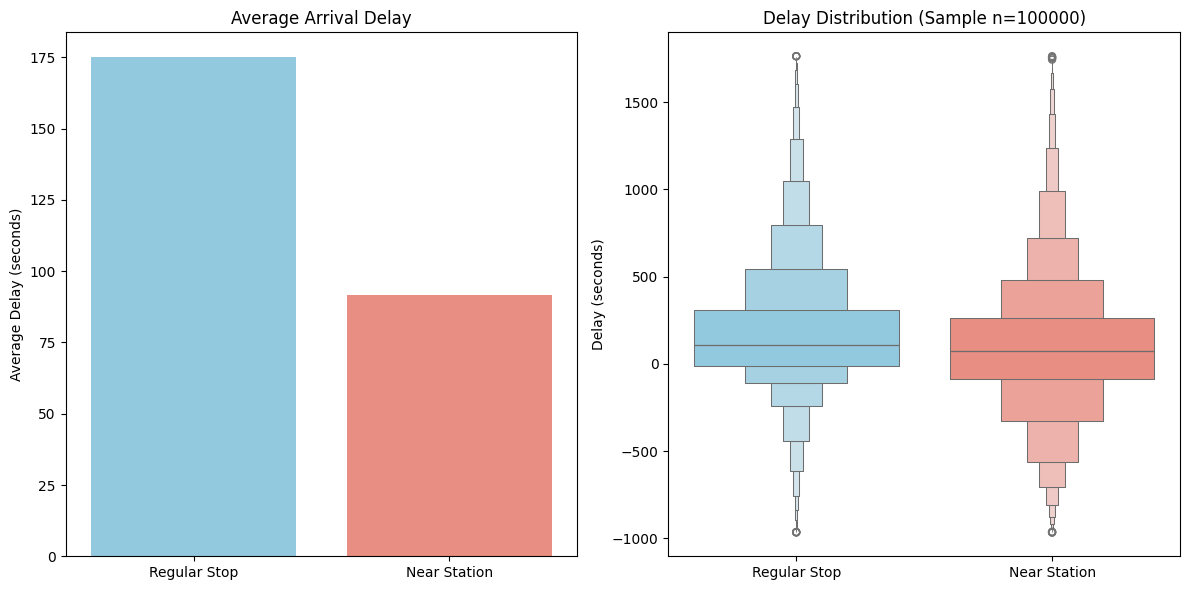


Average Delay Increase at Station Stops: -83.53 seconds
  - Regular Stops avg: 175.04 s
  - Near Station avg:  91.52 s


In [23]:
# ==========================================
# Statistical Analysis: Station Proximity vs Delay
# ==========================================

# 1. Apply the station flag to the entire dataset
# Ensure stop_id is string
base_df_filtered['stop_id'] = base_df_filtered['stop_id'].astype(str)

# Create binary flag
base_df_filtered['is_near_station'] = base_df_filtered['stop_id'].isin(station_connected_stop_ids)

# 2. Calculate Statistics
station_stats = base_df_filtered.groupby('is_near_station')['arrival_delay'].agg(['mean', 'median', 'std', 'count']).reset_index()
station_stats['Label'] = station_stats['is_near_station'].map({True: 'Near Station', False: 'Regular Stop'})

print("--- Delay Statistics by Station Proximity ---")
print(station_stats[['Label', 'mean', 'median', 'std', 'count']])

# 3. Visualize
plt.figure(figsize=(12, 6))

# Bar plot for Means
plt.subplot(1, 2, 1)
sns.barplot(x='Label', y='mean', data=station_stats, hue='Label', palette=['skyblue', 'salmon'], legend=False)
plt.title('Average Arrival Delay')
plt.ylabel('Average Delay (seconds)')
plt.xlabel('')

# Boxen plot for Distribution (better for large datasets than boxplot)
plt.subplot(1, 2, 2)
# Sample data for plotting if dataset is too large, to speed up visualization
sample_size = min(100000, len(base_df_filtered))
sns.boxenplot(x='is_near_station', y='arrival_delay', data=base_df_filtered.sample(sample_size), hue='is_near_station', palette=['skyblue', 'salmon'], legend=False)
plt.xticks([0, 1], ['Regular Stop', 'Near Station'])
plt.title(f'Delay Distribution (Sample n={sample_size})')
plt.xlabel('')
plt.ylabel('Delay (seconds)')

plt.tight_layout()
plt.show()

# 4. Difference
mean_near = station_stats.loc[station_stats['is_near_station'] == True, 'mean'].values[0]
mean_regular = station_stats.loc[station_stats['is_near_station'] == False, 'mean'].values[0]
mean_diff = mean_near - mean_regular

print(f"\nAverage Delay Increase at Station Stops: {mean_diff:.2f} seconds")
print(f"  - Regular Stops avg: {mean_regular:.2f} s")
print(f"  - Near Station avg:  {mean_near:.2f} s")

駅周辺とそれ以外のバス停のデータ比率は約1:4ですが、十分なサンプル数が確保されているため、サンプリングを行わずに統計的手法を用いて差異を比較します。

Analyzing 3822946 records at stops near stations...

--- Delay at Stations: Trip Start vs En-Route ---
                        Condition        mean  median         std    count
0  En-Route (Passing/Terminating)  205.361375   128.0  320.674621  2511928
1             Trip Start (Origin) -126.612537  -113.0  434.823330  1311018


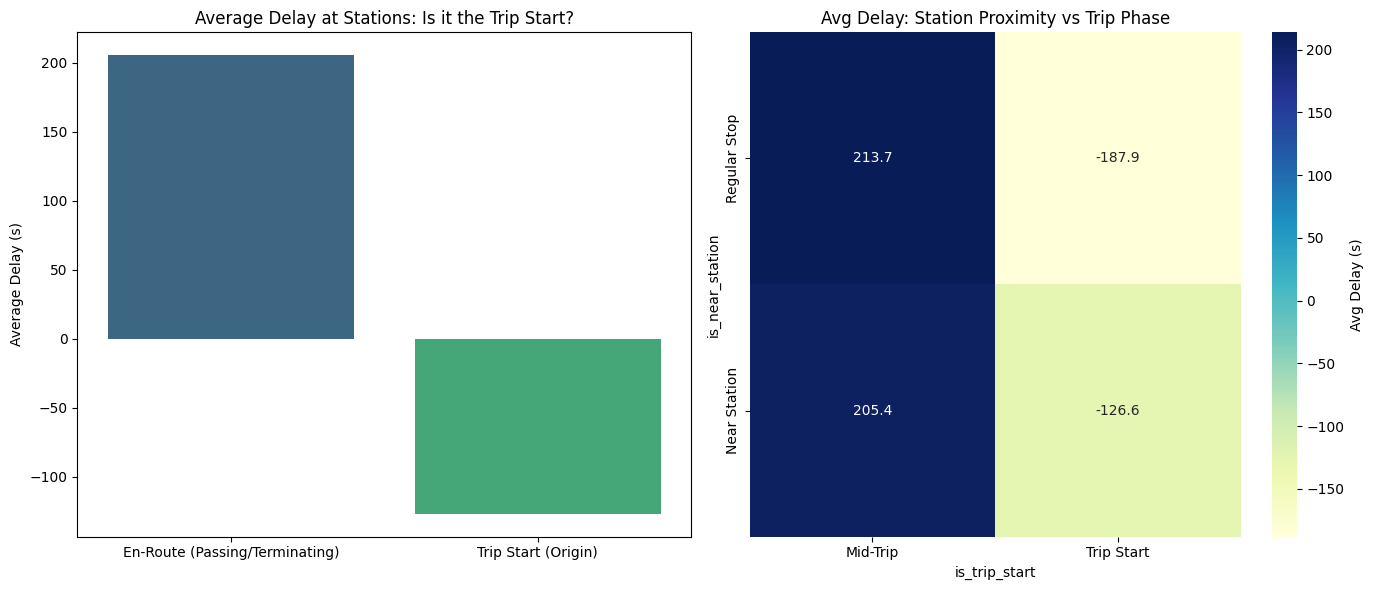

In [24]:
# ==========================================
# Deep Dive: Station Stops - Trip Start vs En-Route
# ==========================================

# We want to see if delays at stations are due to the bus originating there (waiting for departure)
# or passing through (delayed arrival).

# 1. Flag Trip Starts
# Assumption: stop_sequence 1 is the start. 
base_df_filtered['is_trip_start'] = base_df_filtered['stop_sequence'] == 1

# 2. Filter: Only look at stops Near Stations
station_subset = base_df_filtered[base_df_filtered['is_near_station']].copy()

print(f"Analyzing {len(station_subset)} records at stops near stations...")

# Check if we have data for both conditions
if station_subset['is_trip_start'].nunique() > 1:
    # 3. Compare Start vs En-Route
    trip_start_stats = station_subset.groupby('is_trip_start')['arrival_delay'].agg(['mean', 'median', 'std', 'count']).reset_index()
    trip_start_stats['Condition'] = trip_start_stats['is_trip_start'].map({True: 'Trip Start (Origin)', False: 'En-Route (Passing/Terminating)'})

    print("\n--- Delay at Stations: Trip Start vs En-Route ---")
    print(trip_start_stats[['Condition', 'mean', 'median', 'std', 'count']])

    # 4. Visualization
    plt.figure(figsize=(14, 6))

    # A. Impact at Stations
    plt.subplot(1, 2, 1)
    sns.barplot(x='Condition', y='mean', data=trip_start_stats, hue='Condition', palette='viridis', legend=False)
    plt.title('Average Delay at Stations: Is it the Trip Start?')
    plt.ylabel('Average Delay (s)')
    plt.xlabel('')

    # B. Interaction Heatmap: Station Proximity x Trip Start (All Data)
    # To see the broad picture
    plt.subplot(1, 2, 2)
    pivot_interaction = base_df_filtered.pivot_table(
        index='is_near_station', 
        columns='is_trip_start', 
        values='arrival_delay', 
        aggfunc='mean'
    )
    # Rename for display
    pivot_interaction.index = pivot_interaction.index.map({True: 'Near Station', False: 'Regular Stop'})
    pivot_interaction.columns = pivot_interaction.columns.map({True: 'Trip Start', False: 'Mid-Trip'})

    sns.heatmap(pivot_interaction, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Avg Delay (s)'})
    plt.title('Avg Delay: Station Proximity vs Trip Phase')

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data variability in 'is_trip_start' for station stops.")

始発バス停と経由地バス停での遅延比較において、始発バス停では遅延が顕著に小さいことが確認されました。
また、始発以外であっても、駅周辺のバス停の方が非駅周辺と比較して若干遅延が小さい傾向が見られます。

--- Delay Statistics by Stop Connectivity ---
               Label        mean  median         std     count
0  Single-Route Stop  115.133562    78.0  369.281824   5944849
1    Multi-Route Hub  178.701950   115.0  369.403480  10061192


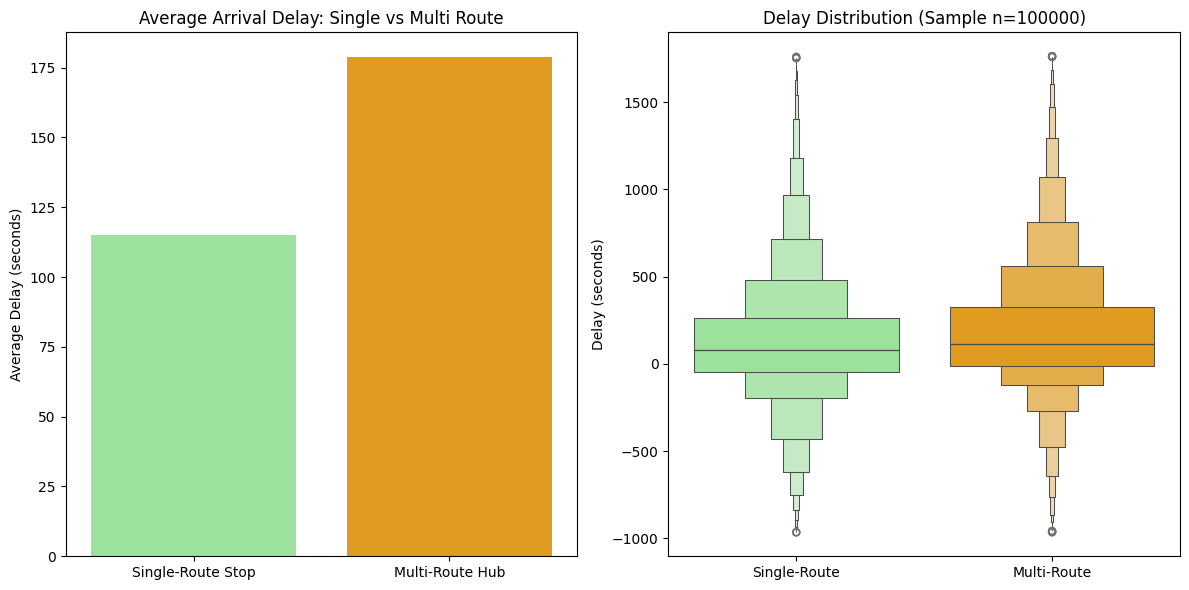

In [25]:
# ==========================================
# Statistical Analysis: Multi-Route Hubs vs Delay
# ==========================================

# 1. Reuse stop_route_counts from previous analysis
base_df_filtered['is_multi_route'] = base_df_filtered['route_count_at_stop'] > 1

# 3. Calculate Statistics
hub_stats = base_df_filtered.groupby('is_multi_route')['arrival_delay'].agg(['mean', 'median', 'std', 'count']).reset_index()
hub_stats['Label'] = hub_stats['is_multi_route'].map({True: 'Multi-Route Hub', False: 'Single-Route Stop'})

print("--- Delay Statistics by Stop Connectivity ---")
print(hub_stats[['Label', 'mean', 'median', 'std', 'count']])

# 4. Visualize
plt.figure(figsize=(12, 6))

# Bar plot for Means
plt.subplot(1, 2, 1)
sns.barplot(x='Label', y='mean', data=hub_stats, hue='Label', palette=['lightgreen', 'orange'], legend=False)
plt.title('Average Arrival Delay: Single vs Multi Route')
plt.ylabel('Average Delay (seconds)')
plt.xlabel('')

# Boxen plot for Distribution
plt.subplot(1, 2, 2)
sample_size = min(100000, len(base_df_filtered))
sns.boxenplot(x='is_multi_route', y='arrival_delay', hue='is_multi_route', data=base_df_filtered.sample(sample_size), palette=['lightgreen', 'orange'], legend=False)
plt.xticks([0, 1], ['Single-Route', 'Multi-Route'])
plt.title(f'Delay Distribution (Sample n={sample_size})')
plt.xlabel('')
plt.ylabel('Delay (seconds)')

plt.tight_layout()
plt.show()

複数路線が乗り入れるバス停（ハブ）と単独路線のバス停を比較すると、複数路線が乗り入れるバス停の方が遅延が大きい傾向にあります。

Correlation Coefficient (All Data): 0.0487
Correlation Coefficient (Excluding Single-Route Stops): -0.0023


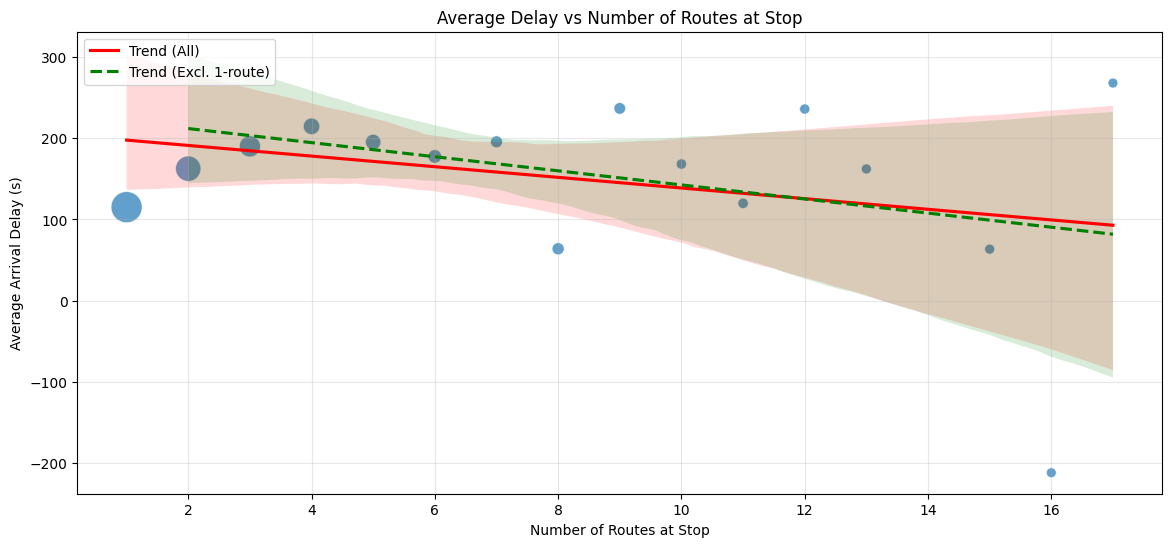

In [26]:
# ==========================================
# Correlation Analysis: Route Count vs Delay
# ==========================================

# 1. Group by Route Count and calculate statistics
delay_by_count = base_df_filtered.groupby('route_count_at_stop')['arrival_delay'].agg(['mean', 'count', 'std']).reset_index()
delay_by_count_stable = delay_by_count[delay_by_count['count'] > 100]

# 2. Visualization
plt.figure(figsize=(14, 6))

sns.scatterplot(data=delay_by_count_stable, x='route_count_at_stop', y='mean', size='count', sizes=(50, 500), alpha=0.7, legend=False)

# Trend line for ALL data
sns.regplot(data=delay_by_count_stable, x='route_count_at_stop', y='mean', scatter=False, color='red', label='Trend (All)')

# Trend line for Multi-Route Only (>1)
sns.regplot(
    data=delay_by_count_stable[delay_by_count_stable['route_count_at_stop'] > 1], 
    x='route_count_at_stop', 
    y='mean', 
    scatter=False, 
    color='green', 
    line_kws={'linestyle': '--'}, # Correct way to pass linestyle
    label='Trend (Excl. 1-route)'
)

plt.title('Average Delay vs Number of Routes at Stop')
plt.xlabel('Number of Routes at Stop')
plt.ylabel('Average Arrival Delay (s)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Correlation Coefficients
corr_all = base_df_filtered[['route_count_at_stop', 'arrival_delay']].corr().iloc[0, 1]
print(f"Correlation Coefficient (All Data): {corr_all:.4f}")

subset_multi = base_df_filtered[base_df_filtered['route_count_at_stop'] > 1]
corr_multi = subset_multi[['route_count_at_stop', 'arrival_delay']].corr().iloc[0, 1]
print(f"Correlation Coefficient (Excluding Single-Route Stops): {corr_multi:.4f}")

乗り入れ路線数と遅延の相関を確認した結果、強い線形相関は見られませんでした。
-> 示唆：特徴量エンジニアリングにおいては、路線数そのものよりも「複数路線か否か（ハブか否か）」を示すフラグの方が有効であると考えられます。

## Environmental Factors
Google Places APIを用いて取得したバス停周辺の施設情報（POI）に基づき、周辺環境と遅延との関係性を分析します。

In [27]:
base_df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16006041 entries, 0 to 16006040
Data columns (total 35 columns):
 #   Column                     Dtype                            
---  ------                     -----                            
 0   route_id                   object                           
 1   trip_id                    object                           
 2   start_date                 object                           
 3   arrival_day_offset         int64                            
 4   direction_id               int64                            
 5   stop_id                    object                           
 6   stop_sequence              int64                            
 7   region_id                  object                           
 8   lat_sin                    float64                          
 9   lat_cos                    float64                          
 10  lon_sin                    float64                          
 11  lon_cos               

In [28]:
stop_stats = base_df_filtered[base_df_filtered['hour_of_day'].isin(range(10, 20))].groupby('stop_id').agg({'arrival_delay': 'mean'}).rename(columns={'arrival_delay': 'avg_delay'}).reset_index()

google_types_df = pd.read_csv(const.STOP_GOOGLE_TYPES_CSV)
google_types_df['stop_id'] = google_types_df['stop_id'].astype(str)
stop_stats = stop_stats.merge(google_types_df, on='stop_id', how='left')

In [29]:
import statsmodels.api as sm

# 1. Parse types and Count frequencies
google_types_df['types_list'] = google_types_df['google_types'].apply(lambda x: x.split(',') if isinstance(x, str) else [])

type_counts = {}
total_stops = len(google_types_df)
for types in google_types_df['types_list']:
    for t in types:
        type_counts[t] = type_counts.get(t, 0) + 1

type_freq_df = pd.DataFrame(list(type_counts.items()), columns=['type', 'count'])
type_freq_df['frequency'] = type_freq_df['count'] / total_stops
type_freq_df = type_freq_df.sort_values('frequency', ascending=False)

print("--- Top 10 Most Common Google Place Types ---")
print(type_freq_df.head(10))

# 2. Identify "Too Common" types (e.g. > 90% coverage or generic tags)
# 'political', 'locality' are often administrative tags present everywhere.
# 'transit_station' is naturally common for bus stops.
high_freq_threshold = 0.90
too_common_types = type_freq_df[type_freq_df['frequency'] > high_freq_threshold]['type'].tolist()
manual_exclusions = ['point_of_interest', 'establishment'] 
exclude_types = set(too_common_types + manual_exclusions)

print(f"\nExcluding {len(exclude_types)} types (High frequency or Generic): {exclude_types}")

# 3. Efficient One-hot encoding
# Using str.get_dummies is faster and cleaner
google_types_encoded = google_types_df.set_index('stop_id')['google_types'].str.get_dummies(sep=',').reset_index()
google_types_encoded = google_types_encoded.add_prefix('type_')
google_types_encoded.rename(columns={'type_stop_id': 'stop_id'}, inplace=True)

# 4. Merge and Prepare Data
stop_stats_with_types = pd.merge(stop_stats, google_types_encoded, on='stop_id', how='left')
stop_stats_with_types.fillna(0, inplace=True)

# Select columns excluding the common ones
type_columns = [
    col for col in stop_stats_with_types.columns 
    if col.startswith('type_') and col.replace('type_', '') not in exclude_types
]

print(f"\nSelected {len(type_columns)} feature types for analysis.")

X = stop_stats_with_types[type_columns].astype(float)
y = stop_stats_with_types['avg_delay'].astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print("\nRegression Results Summary:")
print(model.summary())

--- Top 10 Most Common Google Place Types ---
                 type  count  frequency
13  point_of_interest   8806   0.997847
4       establishment   8806   0.997847
20    transit_station   8631   0.978017
17              route   8543   0.968045
14          political   8225   0.932011
8            locality   8201   0.929292
18              store   2215   0.250992
25             health   1784   0.202153
5                food   1781   0.201813
16         restaurant   1260   0.142776

Excluding 6 types (High frequency or Generic): {'locality', 'transit_station', 'political', 'establishment', 'route', 'point_of_interest'}

Selected 98 feature types for analysis.

Regression Results Summary:
                            OLS Regression Results                            
Dep. Variable:              avg_delay   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:               

9割以上のバス停に含まれる高頻度カテゴリ（一般的なタグ）を除外した後、残りの施設カテゴリを用いて重回帰分析を行います。各カテゴリの係数（Coefficient）を確認することで、遅延に寄与する特定の施設タイプを特定します。

Significant Factors (p < 0.05): 9

--- Top Factors Increasing Delay ---
type_tourist_attraction         41.601009
type_grocery_or_supermarket     25.419329
type_store                      13.796007
type_general_contractor         11.698302
type_real_estate_agency        -19.597740
type_park                      -24.454738
type_supermarket               -37.998041
type_bus_station               -90.356385
type_bowling_alley            -179.559076
dtype: float64

--- Top Factors Decreasing Delay ---
type_tourist_attraction         41.601009
type_grocery_or_supermarket     25.419329
type_store                      13.796007
type_general_contractor         11.698302
type_real_estate_agency        -19.597740
type_park                      -24.454738
type_supermarket               -37.998041
type_bus_station               -90.356385
type_bowling_alley            -179.559076
dtype: float64


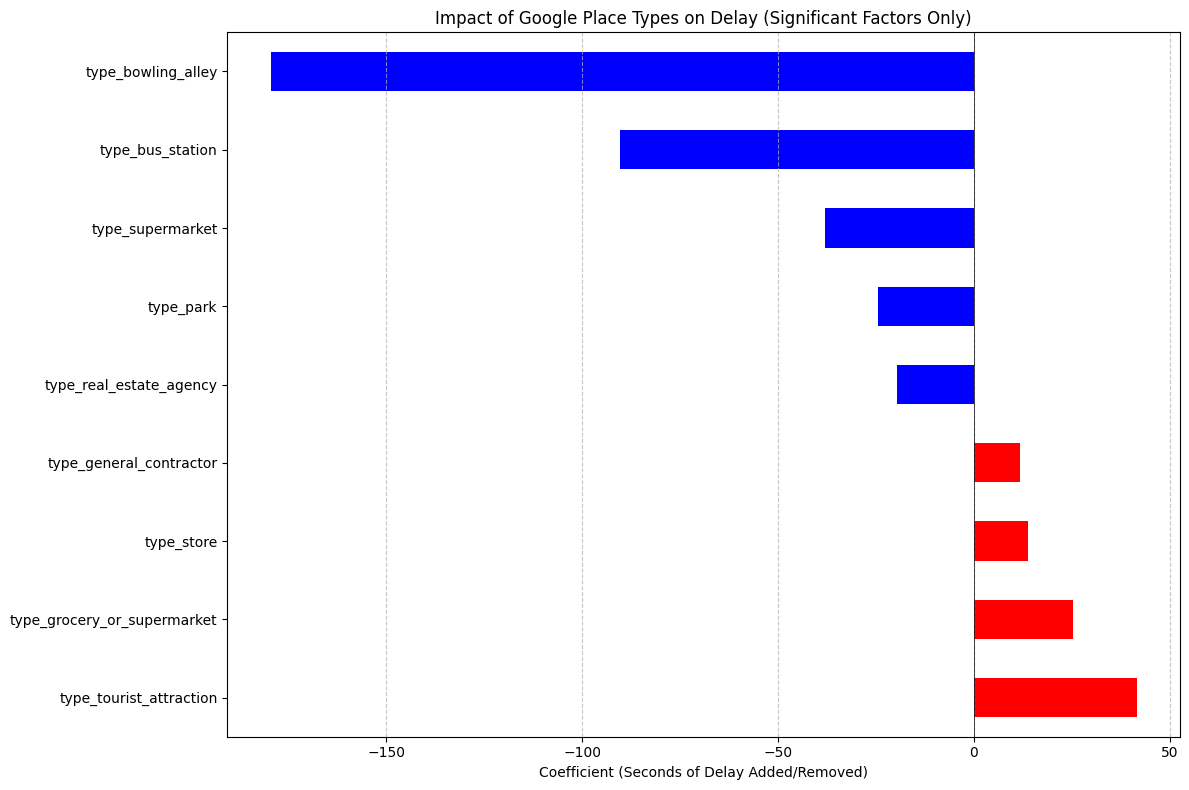

In [30]:
# Filter Significant Factors (p < 0.05)
significant_factors = model.pvalues[model.pvalues < 0.05].index.tolist()
significant_factors = [f for f in significant_factors if f != 'const']
significant_factors_sorted = model.params[significant_factors].sort_values(ascending=False)

print(f"Significant Factors (p < 0.05): {len(significant_factors)}")
print("\n--- Top Factors Increasing Delay ---")
print(significant_factors_sorted.head(10))

print("\n--- Top Factors Decreasing Delay ---")
print(significant_factors_sorted.tail(10))

# Visualize Coefficients of Significant Factors
plt.figure(figsize=(12, 8))

# Sort by coefficient value for better plotting
plot_data = significant_factors_sorted

# Color bars: Red for positive (delay increase), Blue for negative (delay decrease)
colors = ['red' if x > 0 else 'blue' for x in plot_data.values]

plot_data.plot(kind='barh', color=colors)
plt.title('Impact of Google Place Types on Delay (Significant Factors Only)')
plt.xlabel('Coefficient (Seconds of Delay Added/Removed)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
# 1. Base: All Stops
static_stops_df = pd.read_csv(const.STOPS_TXT, usecols=['stop_id'])
static_stops_df['stop_id'] = static_stops_df['stop_id'].astype(str)

# 2. Add 'is_near_station'
static_stops_df['is_near_station'] = static_stops_df['stop_id'].isin(station_connected_stop_ids).astype(int)

# 3. Add 'is_multi_route' (Calculated in Section 3. Infrastructure)
static_stops_df = static_stops_df.merge(stop_route_counts, on='stop_id', how='left')
static_stops_df['route_count_at_stop'] = static_stops_df['route_count_at_stop'].fillna(0)
static_stops_df['is_multi_route'] = (static_stops_df['route_count_at_stop'] > 1).astype(int)
static_stops_df.drop(columns=['route_count_at_stop'], inplace=True)

# 4. Add Google Place Types (Calculated in Section 3. Environment)
g_df = pd.read_csv(const.STOP_GOOGLE_TYPES_CSV)
g_df['stop_id'] = g_df['stop_id'].astype(str)

# Get dummies
dummies = g_df.set_index('stop_id')['google_types'].str.get_dummies(sep=',')
valid_cols = [c for c in dummies.columns if c not in exclude_types]

# Select Top 20
top_types = dummies[valid_cols].sum().sort_values(ascending=False).head(20).index.tolist()
dummies_selected = dummies[top_types].copy()
dummies_selected = dummies_selected.add_prefix('type_')

static_stops_df = static_stops_df.merge(dummies_selected, on='stop_id', how='left')

# Fill NAs
type_cols = [c for c in static_stops_df.columns if c.startswith('type_')]
static_stops_df[type_cols] = static_stops_df[type_cols].fillna(0).astype(int)

# Save to processed data folder
output_path = f"{const.PROCESSED_DATA_DIR}/static_stop_features.csv"
static_stops_df.to_csv(output_path, index=False)
print(f"Static stop features saved to: {output_path}")
print(f"Columns: {static_stops_df.columns.tolist()}")

Static stop features saved to: /workspace/data/processed/static_stop_features.csv
Columns: ['stop_id', 'is_near_station', 'is_multi_route', 'type_store', 'type_health', 'type_food', 'type_restaurant', 'type_finance', 'type_general_contractor', 'type_beauty_salon', 'type_hair_care', 'type_cafe', 'type_atm', 'type_bus_station', 'type_meal_takeaway', 'type_home_goods_store', 'type_dentist', 'type_doctor', 'type_convenience_store', 'type_clothing_store', 'type_real_estate_agency', 'type_spa', 'type_bakery']


# 4. Conclusion and Next Steps

## 分析結果の要約 (Key Findings)
1.  **データ品質**:
    *   遅延の約98%は-15分から30分の範囲に収束しています。
    *   一部のバス停でRegion IDの欠損が見られました。
2.  **時系列特性 (Temporal Pattern)**:
    *   朝(7時)と夕方(17時)にピークを持ちますが、夕方は帰宅時間の分散によりピークが緩やかです。
    *   金曜日は遅延が最大、月曜日は最小となる傾向があります。
3.  **地理的特性 (Spatial Pattern)**:
    *   運行本数はダウンタウン・UBCで多い一方、遅延は郊外（特にLangley, Bridgeport周辺）や渡河ルートで顕著です。
4.  **影響要因 (Factors)**:
    *   **Alert**: 発生時に約1分の遅延増加が見られます。
    *   **Infrastructure**: 鉄道駅周辺（特に始発）は遅延が小さく、複数路線が乗り入れるハブバス停では遅延が大きい傾向があります。
    *   **Environment**: バス停周辺の特定施設タイプが遅延と統計的に有意な関連を持っています。

## 次のステップ (Process Phase Plan)
分析結果に基づき、以下のデータ処理・特徴量エンジニアリングを実施します。

1.  **フィルタリング**:
    *   遅延データの1%点および99%点を用いて外れ値を除去し、分析対象範囲を限定します。
2.  **データ補完・集約**:
    *   Tripごとのデータ集約: 1トリップ・1バス停につき1レコードとなるよう、遅延データの線形補間（Linear Interpolation）を行います。
    *   Region ID欠損値の補完（Stop 9956 -> 'maple_ridge'）。
3.  **特徴量エンジニアリング**:
    *   **時間的特徴量**:
        *   `hour`, `day_of_week`, `is_weekend` の抽出。
        *   周期的特徴量: `time_sin`, `time_cos` (24時間周期) の作成。
        *   ラッシュアワーフラグ: `is_morning_rush_hour` (7時), `is_evening_rush_hour` (16-19時)。
    *   **地理的特徴量**: `Region One-hot Encoding` の実施。
    *   **Infrastructure**:
        *   `is_near_station`: 鉄道駅（Skytrain/Westcoast Express）から半径500m以内のバス停フラグ。
        *   `is_multi_route`: 複数路線が乗り入れるバス停（ハブ）フラグ。
    *   **Environment**:
        *   Google Places APIから得られた施設タイプ（`google_types`）のOne-hot Encoding（出現頻度の高い主要カテゴリを選定）。
    *   **Alert**: 警察活動 (`has_police_alert`) および迂回 (`has_detour`) のバイナリフラグ作成。
    *   **Lag特徴量**: 同一ルート・方向における過去5回のトリップの遅延実績 (`lag_arrival_delay_1` ~ `lag_arrival_delay_5`) を追加。
    *   **その他**: Route/Directionの`Label Encoding`。